In [18]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [19]:
import cv2

cap = cv2.VideoCapture(0)

print(cap.isOpened())

cap.release()

True


In [20]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    cv2.imshow("Laptop Camera", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


Stopped by user
Camera released


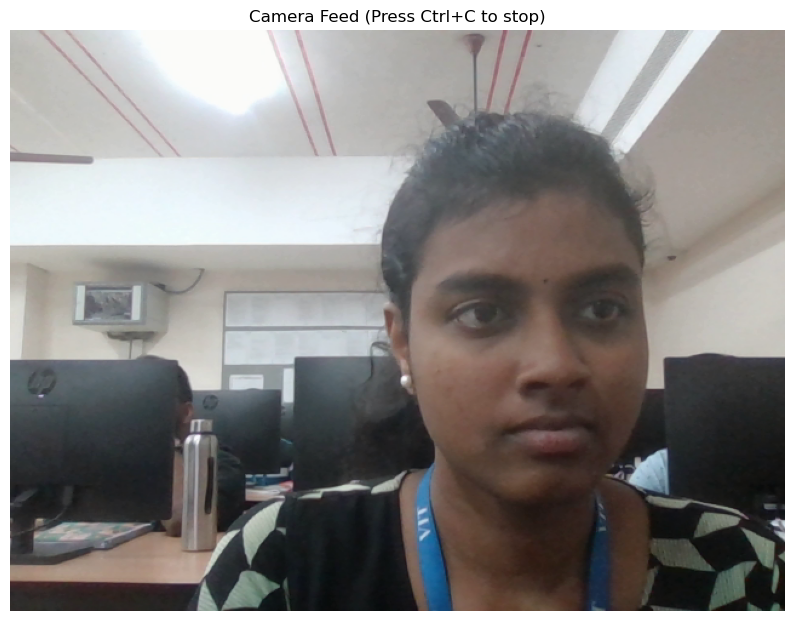

In [22]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time
import numpy as np

# Try to open the camera
cap = cv2.VideoCapture(0)

# Check if camera opened successfully and try alternatives if it didn't
if not cap.isOpened():
    print("Could not open camera with index 0, trying alternative indices...")
    
    # Try different camera indices
    for i in range(1, 5):
        cap = cv2.VideoCapture(i)
        if cap.isOpened():
            print(f"Successfully opened camera with index {i}")
            break
    
    # If still not open, create a dummy video
    if not cap.isOpened():
        print("Could not open any camera. Using a dummy colored pattern instead.")
        
        def generate_dummy_frame(frame_count):
            """Generate a colored pattern that changes over time"""
            h, w = 480, 640
            frame = np.zeros((h, w, 3), dtype=np.uint8)
            
            # Create a time-varying pattern
            for i in range(h):
                for j in range(w):
                    r = (i + frame_count) % 255
                    g = (j + frame_count) % 255
                    b = (i + j + frame_count) % 255
                    frame[i, j] = [r, g, b]
            
            return frame

# Main loop
frame_count = 0
try:
    while True:
        if cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame from camera, using dummy frame")
                frame = generate_dummy_frame(frame_count)
            else:
                # Convert BGR to RGB (OpenCV uses BGR, matplotlib uses RGB)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        else:
            # Use dummy frame if no camera
            frame = generate_dummy_frame(frame_count)
        
        # Display using matplotlib
        clear_output(wait=True)
        plt.figure(figsize=(10, 8))
        plt.imshow(frame)
        plt.title("Camera Feed (Press Ctrl+C to stop)")
        plt.axis('off')
        display(plt.gcf())
        plt.close()
        
        # Increment frame count for dummy video
        frame_count += 1
        
        # Add a small delay
        time.sleep(0.1)
        
except KeyboardInterrupt:
    print("Stopped by user")
finally:
    # Release the camera if it was opened
    if cap.isOpened():
        cap.release()
    print("Camera released")

In [28]:
# display video properties
import cv2

cap = cv2.VideoCapture("sample.mp4")

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video file")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

    print("Total Frames:", total_frames)
    print("FPS:", fps)
    print("Width:", width)
    print("Height:", height)

cap.release()

Total Frames: 2348
FPS: 29.97002997002997
Width: 1920.0
Height: 1080.0


In [29]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # draw rectangle
    cv2.rectangle(frame, (100,100), (300,300), (0,255,0), 3)

    # draw circle
    cv2.circle(frame, (200,200), 50, (255,0,0), 3)

    # add text
    cv2.putText(frame, "OpenCV Practice", (50,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    cv2.imshow("Shapes", frame)

    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


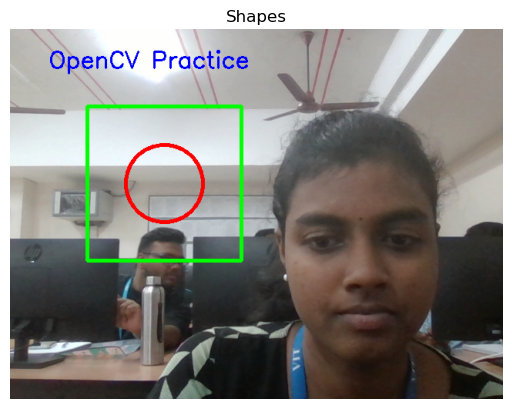

Camera released


In [31]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open camera.")

else:
    try:
        for i in range(10):   # capture 10 frames
            
            ret, frame = cap.read()

            if not ret:
                print("Failed to grab frame")
                break

            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Draw rectangle
            cv2.rectangle(frame, (100,100), (300,300), (0,255,0), 3)

            # Draw circle
            cv2.circle(frame, (200,200), 50, (255,0,0), 3)

            # Add text
            cv2.putText(frame, "OpenCV Practice", (50,50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

            # Clear previous output
            clear_output(wait=True)

            # Display frame
            plt.imshow(frame)
            plt.title("Shapes")
            plt.axis("off")
            display(plt.gcf())
            plt.close()

            time.sleep(0.5)

    finally:
        cap.release()
        print("Camera released")

In [32]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    edges = cv2.Canny(frame, 100, 200)

    cv2.imshow("Edges", edges)

    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [34]:
import cv2

# Open webcam
cap = cv2.VideoCapture(0)

# Check if camera opened
if not cap.isOpened():
    print("Error: Cannot open camera")
    exit()

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    # Edge detection
    edges = cv2.Canny(frame, 100, 200)

    # Show edges
    cv2.imshow("Edges", edges)

    # Press q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release camera
cap.release()

# Close windows
cv2.destroyAllWindows()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [35]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")

else:
    for i in range(20):   # capture 20 frames
        
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Edge detection
        edges = cv2.Canny(frame, 100, 200)

        # Clear previous frame
        clear_output(wait=True)

        # Show edges
        plt.imshow(edges, cmap='gray')
        plt.title("Edges")
        plt.axis("off")
        plt.show()

        time.sleep(0.1)

cap.release()

Failed to grab frame


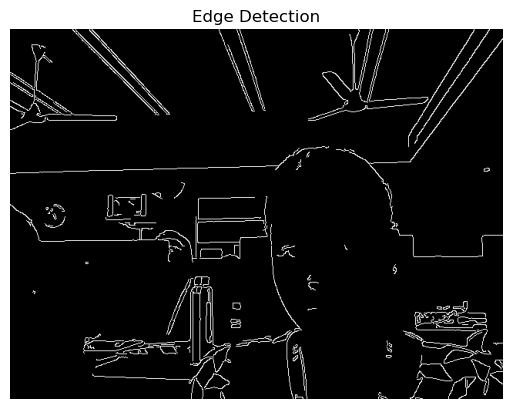

In [36]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Try opening webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot access camera. Try another index like 1.")
else:
    for i in range(20):  # capture 20 frames
        
        ret, frame = cap.read()

        if not ret:
            print("Failed to grab frame")
            break

        # Convert to grayscale (better for edge detection)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Edge detection
        edges = cv2.Canny(gray, 100, 200)

        clear_output(wait=True)

        plt.imshow(edges, cmap='gray')
        plt.title("Edge Detection")
        plt.axis("off")
        plt.show()

        time.sleep(0.1)

cap.release()

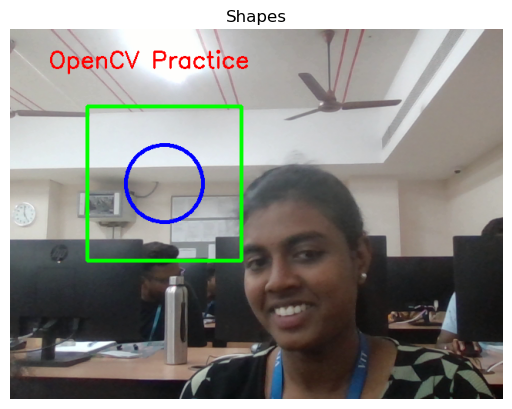

In [39]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# try camera
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera not detected. Trying another index...")
    cap = cv2.VideoCapture(1)

if not cap.isOpened():
    print("Unable to access camera.")
else:
    for i in range(20):

        ret, frame = cap.read()

        if not ret:
            print("Failed to grab frame")
            break

        # draw rectangle
        cv2.rectangle(frame, (100,100), (300,300), (0,255,0), 3)

        # draw circle
        cv2.circle(frame, (200,200), 50, (255,0,0), 3)

        # add text
        cv2.putText(frame, "OpenCV Practice", (50,50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        clear_output(wait=True)

        plt.imshow(frame)
        plt.axis("off")
        plt.title("Shapes")
        plt.show()

        time.sleep(0.1)

cap.release()

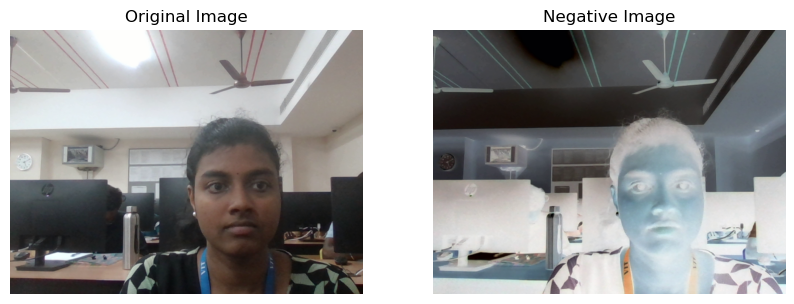

In [41]:
import cv2
import matplotlib.pyplot as plt

# Open camera
cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if not ret:
    print("Failed to capture frame")
else:
    
    # Convert BGR to RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Negative image using formula
    negative = 255 - frame_rgb

    # Display images
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(frame_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(negative)
    plt.title("Negative Image")
    plt.axis("off")

    plt.show()

cap.release()

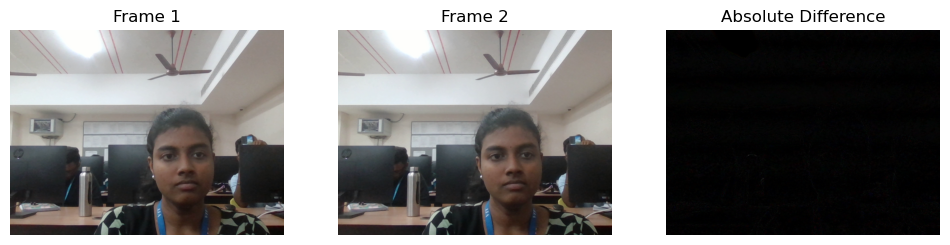

In [42]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

# Capture first frame
ret, frame1 = cap.read()

# Capture second frame
ret, frame2 = cap.read()

# Compute absolute difference
diff = cv2.absdiff(frame1, frame2)

# Convert for display
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
diff = cv2.cvtColor(diff, cv2.COLOR_BGR2RGB)

# Display images
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(frame1)
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(frame2)
plt.title("Frame 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(diff)
plt.title("Absolute Difference")
plt.axis("off")

plt.show()

cap.release()

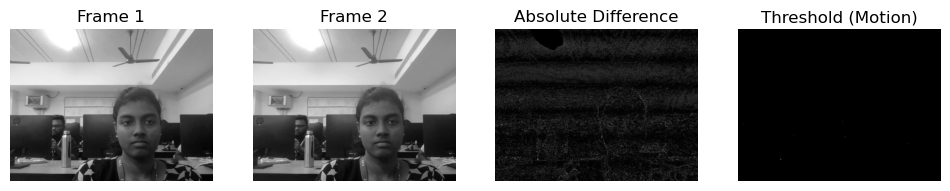

In [43]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

# Capture first frame
ret, frame1 = cap.read()

# Capture second frame
ret, frame2 = cap.read()

# Convert frames to grayscale
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Absolute difference
diff = cv2.absdiff(gray1, gray2)

# Apply threshold to highlight motion
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

# Display results
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(gray1, cmap='gray')
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gray2, cmap='gray')
plt.title("Frame 2")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(diff, cmap='gray')
plt.title("Absolute Difference")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold (Motion)")
plt.axis("off")

plt.show()

cap.release()